# ANALIZA PODATKOV O ELEKTRIČNIH AVTOMOBILIH

Analiza temelji na podatkih s spletne strani bestev4me.eu, ki vsebujejo tehnične lastnosti in cene električnih vozil: znamko, model, leto, doseg, porabo, kapaciteto baterije, čas polnjenja, pospešek in ceno.

In [304]:
import pandas as pd


pd.set_option("display.max_rows", 20)
pd.options.display.float_format = '{:,.0f}'.format

%matplotlib inline

AVTOMOBILI = pd.read_csv("podatki/avtomobili.csv")

## Priprava podatkov

Stolpci so urejeni v bolj berljiv vrstni red, vrstice pa razvrščene po znamki, letu in dosegu (padajoče), da so si podobni modeli lažje primerljivi. Izpostavljeni so tudi manjkajoči podatki.

In [305]:
stolpci = ["znamka", "model", "leto"] + [c for c in AVTOMOBILI.columns if c not in ["znamka", "model", "leto", "link"]] + ["link"]
AVTOMOBILI = AVTOMOBILI[stolpci]

AVTOMOBILI = AVTOMOBILI.sort_values(
    ["znamka", "leto", "doseg_[km]"],
    ascending=[True, True, False]
)

AVTOMOBILI

,znamka,model,leto,doseg_[km],poraba_[kWh/100km],kapaciteta_[kWh],cas_polnjenja[min/100km],pospesek(0-100km/h)_[s],cena_[EUR],drzava,link
1172,Abarth,500e Scorpionissima,2023,225,17,37,17,7,"43,000",Italija,https://bestev4me.eu/ev-catalog/1790/abarth-50...
1174,Abarth,500e Hatchback,2023,225,17,37,17,7,"37,990",Italija,https://bestev4me.eu/ev-catalog/1903/abarth-50...
1175,Abarth,500e Convertible,2023,225,17,37,17,7,"40,990",Italija,https://bestev4me.eu/ev-catalog/1904/abarth-50...
1020,Abarth,600e Turismo,2024,280,18,51,15,6,"41,990",Italija,https://bestev4me.eu/ev-catalog/3056/abarth-60...
1021,Abarth,600e Scorpionissima,2024,280,18,51,15,6,"48,990",Italija,https://bestev4me.eu/ev-catalog/3057/abarth-60...
...,...,...,...,...,...,...,...,...,...,...,...
812,Zeekr,X Privilege AWD,2026,350,19,65,11,4,"47,990",Kitajska,https://bestev4me.eu/ev-catalog/3586/zeekr-x-p...
931,Zeekr,X Long Range RWD,2026,320,18,59,9,6,"42,990",Kitajska,https://bestev4me.eu/ev-catalog/3585/zeekr-x-l...
1092,Zeekr,X Core RWD,2026,260,18,47,18,6,"37,990",Kitajska,https://bestev4me.eu/ev-catalog/3584/zeekr-x-c...
1268,e.GO,e.wave X,2022,150,18,27,120,12,"24,990",Nemčija,https://bestev4me.eu/ev-catalog/1896/ego-ewave...


In [306]:
manjkajoce_vrednosti = AVTOMOBILI.isna().sum()
manjkajoce_vrednosti

znamka                       0
model                        0
leto                         0
doseg_[km]                   0
poraba_[kWh/100km]           0
kapaciteta_[kWh]             0
cas_polnjenja[min/100km]     0
pospesek(0-100km/h)_[s]      0
cena_[EUR]                  74
drzava                       0
link                         0
dtype: int64

## Analiza cen

NAJCENEJŠI AVTOMOBILI:

In [307]:
cene_podtabela = AVTOMOBILI[["znamka", "model", "leto", "cena_[EUR]", "drzava"]].copy()

top10_najcenejsa = cene_podtabela.sort_values("cena_[EUR]", ascending=True).head(10)
top10_najcenejsa

,znamka,model,leto,cena_[EUR],drzava
1257,Dacia,Spring Electric 45,2024,"16,900",Romunija
1258,Dacia,Spring Electric 70,2025,"18,700",Romunija
1178,Leapmotor,T03,2024,"18,900",Kitajska
1264,Dacia,Spring Electric 65,2024,"18,900",Romunija
1296,Smart,EQ forfour,2020,"19,120",Nemčija
1265,Dacia,Spring Electric 100,2025,"19,700",Romunija
1227,Renault,Twingo E-Tech 27.5 kWh,2025,"19,990",Francija
1245,Citroen,ë-C3 Urban Range 30 kWh,2025,"19,990",Francija
1262,Dacia,Spring Electric,2021,"20,490",Romunija
1261,Dacia,Spring Electric,2021,"20,490",Romunija


NAJDRAŽJI AVTOMOBILI:

In [308]:
top10_najdrazja = cene_podtabela.sort_values("cena_[EUR]", ascending=False).head(10)
top10_najdrazja


,znamka,model,leto,cena_[EUR],drzava
37,Ferrari,Luce,2026,"550,000",Italija
132,Rolls-Royce,Spectre Series II,2026,"395,060",Združeno kraljestvo
288,Rolls-Royce,Spectre,2023,"379,015",Združeno kraljestvo
65,Lightyear,0,2022,"297,500",Nizozemska
18,Lucid,Air Sapphire,2025,"250,000",ZDA
255,Porsche,Taycan Turbo GT Weissach,2024,"240,000",Nemčija
256,Porsche,Taycan Turbo GT,2024,"240,000",Nemčija
7,Lucid,Air Dream Edition P,2022,"218,000",ZDA
4,Lucid,Air Dream Edition R,2022,"218,000",ZDA
219,Porsche,Taycan Turbo S Cross Turismo,2024,"211,300",Nemčija


RAZPON CEN PO DRŽAVI (izvorna država znamke):

Dodan je tudi stolpec s številom avtomobilov za posamezno državo, da vemo, kako zanesljiva je povprečna cena.

In [309]:
povprecne_cene_po_drzavi = AVTOMOBILI.groupby("drzava")["cena_[EUR]"].agg(["mean", "count"]).round(2)
povprecne_cene_po_drzavi = povprecne_cene_po_drzavi.sort_values("mean", ascending= False)
povprecne_cene_po_drzavi

,mean,count
drzava,,
Nizozemska,"297,500",1
Združeno kraljestvo,"99,376",29
Italija,"78,830",23
Nemčija,"76,298",454
ZDA,"75,910",153
Švedska,"62,429",72
Vietnam,"57,956",8
Češka,"50,596",44
Kitajska,"50,034",132


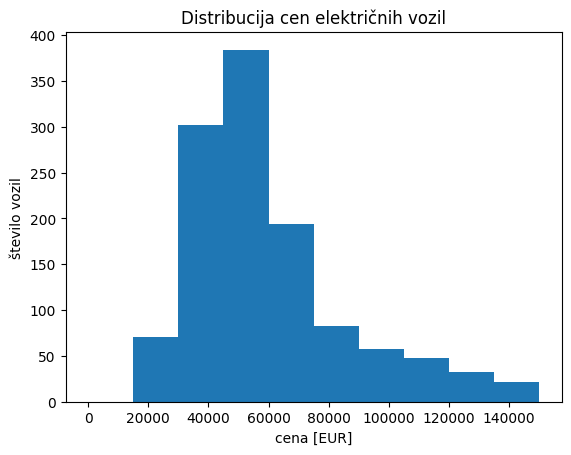

In [310]:


cene = AVTOMOBILI["cena_[EUR]"].dropna().plot.hist(range=(0, 150000))

cene.set_xlabel("cena [EUR]")
cene.set_ylabel("število vozil")
cene.set_title("Distribucija cen električnih vozil");



Zaradi preglednosti so iz grafa izpuščeni najdražji modeli, ki jih je razmeroma malo in ne vplivajo bistveno na obliko grafa.


## Avtomobili z največjim dosegom:

In [311]:
top10_doseg = AVTOMOBILI[["znamka", "model", "leto", "doseg_[km]"]].copy()
top10_doseg = top10_doseg.sort_values("doseg_[km]", ascending=False).head(10)
top10_doseg

,znamka,model,leto,doseg_[km]
0,Mercedes-Benz,EQS 450+,2026,720
1,Lucid,Air Grand Touring,2024,720
2,BMW,i3 50 xDrive,2026,715
4,Lucid,Air Dream Edition R,2022,685
3,Mercedes-Benz,EQS 450+,2024,685
5,Mercedes-Benz,EQS 500 4MATIC,2026,680
9,BMW,iX5 60 xDrive,2026,670
7,Lucid,Air Dream Edition P,2022,670
6,Mercedes-Benz,EQS 580 4MATIC,2026,670
8,Mercedes-Benz,EQS 400,2026,670


## Avtomobili z najboljšo vrednostjo:
Avtomobili z relativno velikim dosegom in nizko ceno.

In [312]:
podtabela_vrednost = AVTOMOBILI[["znamka", "model", "leto", "doseg_[km]", "cena_[EUR]"]].copy()

podtabela_vrednost["cena_na_km"] = (podtabela_vrednost["cena_[EUR]"] / podtabela_vrednost["doseg_[km]"]).round(2)

top10_vrednost = podtabela_vrednost.sort_values("cena_na_km", ascending=True).head(10)
top10_vrednost

,znamka,model,leto,doseg_[km],cena_[EUR],cena_na_km
39,Tesla,Model 3 Long Range RWD,2025,580,"45,970",79
36,Tesla,Model 3 Premium RWD,2025,580,"45,970",79
67,Tesla,Model 3 Long Range RWD,2024,550,"44,990",82
191,TOGG,T10F Long Range RWD,2025,490,"40,118",82
667,Leapmotor,B05 67.1 kWh,2026,380,"31,900",84
1178,Leapmotor,T03,2024,225,"18,900",84
377,Tesla,Model 3 RWD,2025,450,"37,970",84
978,Hyundai,INSTER Long Range,2024,300,"25,400",85
902,GAC,AION UT 60 kWh,2026,330,"28,000",85
145,Kia,EV4 Hatchback 81.4 kWh,2025,505,"43,240",86


## Proizvodnja električnih avtomobilov:
Znamke, ki proizvajajo največ različnih modelov električnih avtomobilov.

<Axes: title={'center': 'Znamke z največ modeli'}, xlabel='znamka'>

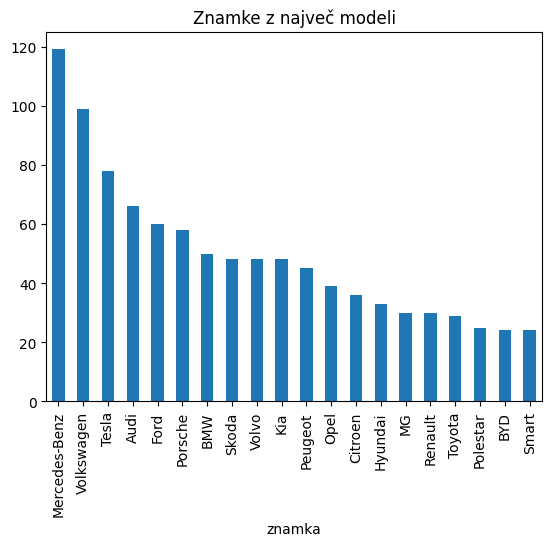

In [313]:
stevilo_modelov = AVTOMOBILI.groupby("znamka").size().sort_values(ascending=False)
top20 = stevilo_modelov.head(20)
top20.plot.bar(title = "Znamke z največ modeli")

## Proizvodnja športnih električnih avtomobilov:
Znamke, ki proizvajajo električne avtomobile z izjemno hitrimi pospeški (v programu je uporabljena meja: manj kot 4s za pospešek od 0-100 km/h).

In [314]:
podtabela_pospesek = AVTOMOBILI[["znamka", "model", "leto", "pospesek(0-100km/h)_[s]", "cena_[EUR]"]].copy()

filter_sportna = podtabela_pospesek["pospesek(0-100km/h)_[s]"] < 4
sportna_vozila = podtabela_pospesek[filter_sportna]

print(len(sportna_vozila))

po_znamki = sportna_vozila.groupby("znamka").size().sort_values(ascending=False)
po_znamki

136


znamka
Porsche          30
Tesla            27
BMW              10
Mercedes-Benz    10
Lucid             9
                 ..
Ferrari           1
Maserati          1
Kia               1
Hongqi            1
XPENG             1
Length: 23, dtype: int64

## Analiza tehnološkega napredka:
Sprememba povprečnih vrednosti dosega, kapacitete baterije, časa polnjenja in porabe tekom let.
Zaradi zanesljivosti povprečnih vrednosti obravnavamo le leta, ko je bilo predstavljenih več kot 10 novih modelov električnih avtomobilov.


In [315]:
napredek_po_letih = AVTOMOBILI.groupby("leto")[ ["doseg_[km]", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]", "poraba_[kWh/100km]"]].mean()
napredek_po_letih["st_avtov"] = AVTOMOBILI.groupby("leto").size()
zanesljiva_leta = napredek_po_letih[napredek_po_letih["st_avtov"] >= 10]
zanesljiva_leta

,doseg_[km],kapaciteta_[kWh],cas_polnjenja[min/100km],poraba_[kWh/100km],st_avtov
leto,,,,,
2015,292,56,34,19,10
2016,314,62,19,19,20
2017,201,37,89,18,16
2018,224,39,38,18,13
2019,349,68,38,20,26
2020,285,58,21,20,81
2021,325,64,16,20,113
2022,392,75,14,19,148
2023,403,76,12,19,175


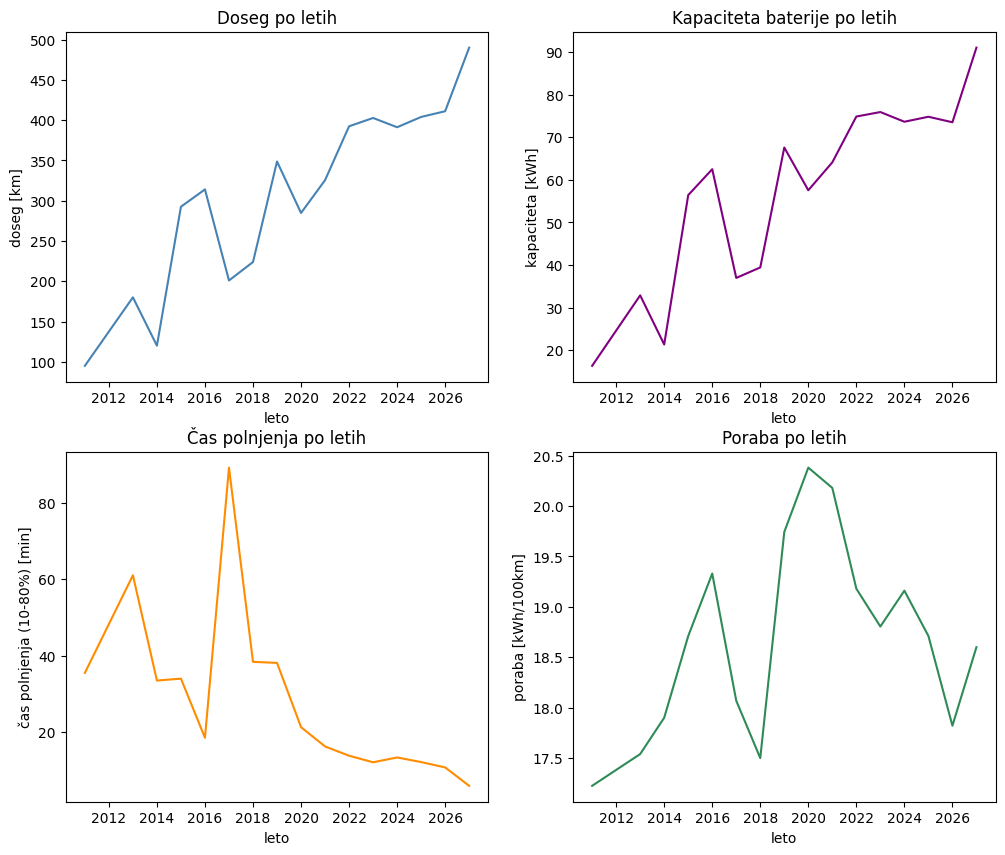

In [316]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

napredek_po_letih["doseg_[km]"].plot(ax=axes[0, 0], color="steelblue", ylabel = "doseg [km]")
axes[0, 0].set_title("Doseg po letih")

napredek_po_letih["kapaciteta_[kWh]"].plot(ax=axes[0, 1], color="purple", ylabel="kapaciteta [kWh]")
axes[0, 1].set_title("Kapaciteta baterije po letih")

napredek_po_letih["cas_polnjenja[min/100km]"].plot(ax=axes[1, 0], color="darkorange", ylabel = "čas polnjenja (10-80%) [min]")
axes[1, 0].set_title("Čas polnjenja po letih")

napredek_po_letih["poraba_[kWh/100km]"].plot(ax=axes[1, 1],color="seagreen", ylabel = "poraba [kWh/100km]" )
axes[1, 1].set_title("Poraba po letih");



V letu 2018 je na vseh grafih opazno odstopanje od trenda, ki ga natančneje pojasni naslednja tabela.

In [317]:
avtomobili_2018 = AVTOMOBILI[AVTOMOBILI["leto"] == 2018]
avtomobili_2018[["znamka", "model", "doseg_[km]", "poraba_[kWh/100km]", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]"]]


,znamka,model,doseg_[km],poraba_[kWh/100km],kapaciteta_[kWh],cas_polnjenja[min/100km]
1144,BMW,i3 120 Ah,235,16,38,23
1161,BMW,i3s 120 Ah,230,16,38,24
1119,Hyundai,Kona Electric 39 kWh,245,16,39,29
646,Jaguar,I-Pace EV400,380,22,85,18
672,Kia,e-Niro 64 kWh,375,17,64,18
1142,Nissan,LEAF 40 kWh,235,17,39,27
1247,Nissan,e-NV200 Evalia,170,22,37,36
1095,Renault,Zoe R90,255,16,41,55
1109,Renault,Zoe R110,250,16,41,55
1120,Renault,Zoe Q90,245,17,41,34


## Grafi korelacije kapacitete baterije
Grafi prikazujejo razmerje med kapaciteto baterije in tremi drugimi spremenljivkami: ceno, dosegom in časom polnjenja. Vsaka pika predstavlja eno vozilo.

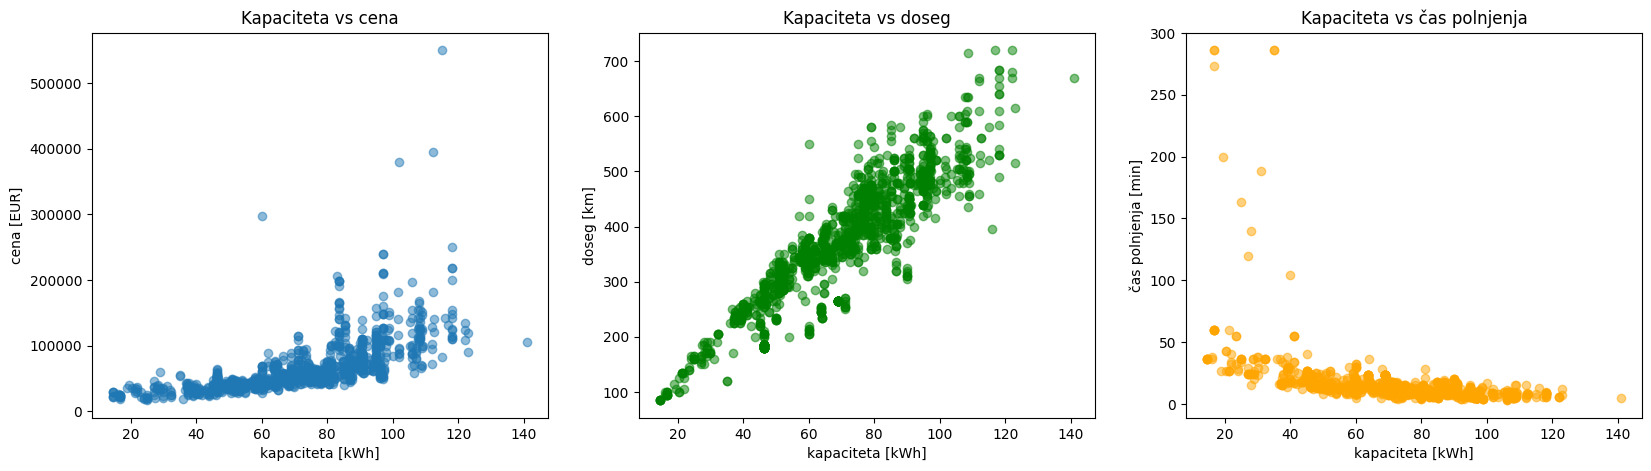

In [318]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["cena_[EUR]"], alpha=0.5)
axes[0].set_xlabel("kapaciteta [kWh]")
axes[0].set_ylabel("cena [EUR]")
axes[0].set_title("Kapaciteta vs cena")

axes[1].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["doseg_[km]"], alpha=0.5, color="green")
axes[1].set_xlabel("kapaciteta [kWh]")
axes[1].set_ylabel("doseg [km]")
axes[1].set_title("Kapaciteta vs doseg")

axes[2].scatter(AVTOMOBILI["kapaciteta_[kWh]"], AVTOMOBILI["cas_polnjenja[min/100km]"], alpha=0.5, color="orange")
axes[2].set_xlabel("kapaciteta [kWh]")
axes[2].set_ylabel("čas polnjenja [min]")
axes[2].set_title("Kapaciteta vs čas polnjenja");



Naslednja tabela prikazuje osamelce s tretjega grafa (z manjšo kapaciteto in daljšim časom polnjenja).

In [319]:
osamelci = AVTOMOBILI[
    (AVTOMOBILI["kapaciteta_[kWh]"] < 40) &
    (AVTOMOBILI["cas_polnjenja[min/100km]"] > 100)
]

osamelci[["znamka", "model", "leto", "kapaciteta_[kWh]", "cas_polnjenja[min/100km]"]].sort_values(
    "cas_polnjenja[min/100km]", ascending=False
)

,znamka,model,leto,kapaciteta_[kWh],cas_polnjenja[min/100km]
1280,Mercedes-Benz,eVito Tourer Extra-Long 41 kWh,2019,35,286
1279,Mercedes-Benz,eVito Tourer Long 41 kWh,2019,35,286
1292,Smart,ForTwo Cabrio Electric Drive,2017,17,286
1291,Smart,ForFour Electric Drive,2017,17,286
1285,Smart,ForTwo Electric Drive,2017,17,273
1282,Ford,Focus Electric,2013,20,200
1259,Renault,Kangoo Maxi ZE 33,2017,31,188
1257,Dacia,Spring Electric 45,2024,25,163
1267,Mercedes-Benz,B 250e,2015,28,140
1268,e.GO,e.wave X,2022,27,120
